# Learn a 3D vector field (gradient of scalar field) with a 5-layer MLP

1. Generate a static 3D Gaussian blob scalar field on a periodic domain
2. Compute the gradient (vector field) via spectral differentiation
3. Train a 5-layer MLP: (x, y, z) -> (gx, gy, gz)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

## 1. Generate the scalar field and its gradient

In [40]:
# Field parameters
L = 1.0          # domain size [0, L)^3, periodic
Nx = 128          # grid resolution
blob_amp = 1.0
blob_sigma = 0.20
blob_center = (0.5, 0.5, 0.5)

dx = L / Nx
coords = torch.arange(Nx, dtype=torch.float64, device=device) * dx
X, Y, Z = torch.meshgrid(coords, coords, coords, indexing='ij')

# Periodic displacement from blob center
def periodic_disp(a, a0, L):
    d = a - a0
    return d - L * torch.round(d / L)

dxp = periodic_disp(X, blob_center[0], L)
dyp = periodic_disp(Y, blob_center[1], L)
dzp = periodic_disp(Z, blob_center[2], L)

r2 = dxp**2 + dyp**2 + dzp**2
c_grid = blob_amp * torch.exp(-0.5 * r2 / blob_sigma**2)

# Spectral gradient
k = 2.0 * torch.pi * torch.fft.fftfreq(Nx, d=dx, device=device, dtype=torch.float64)
kx, ky, kz = torch.meshgrid(k, k, k, indexing='ij')
chat = torch.fft.fftn(c_grid)

gc_x = torch.real(torch.fft.ifftn(1j * kx * chat))
gc_y = torch.real(torch.fft.ifftn(1j * ky * chat))
gc_z = torch.real(torch.fft.ifftn(1j * kz * chat))

print(f'Scalar field shape: {c_grid.shape}')
print(f'Gradient component shape: {gc_x.shape}')

Scalar field shape: torch.Size([128, 128, 128])
Gradient component shape: torch.Size([128, 128, 128])


## 2. Build training data: flatten grid positions and gradient values

In [41]:
# Flatten grid coordinates -> (N, 3) positions
positions = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=1).float()

# Flatten gradient -> (N, 3) targets
grad_targets = torch.stack([gc_x.reshape(-1), gc_y.reshape(-1), gc_z.reshape(-1)], dim=1).float()

# Normalize targets for easier training
grad_scale = grad_targets.abs().max()
grad_targets_norm = grad_targets / grad_scale

print(f'Training samples: {positions.shape[0]}')
print(f'Gradient scale factor: {grad_scale:.4f}')

Training samples: 2097152
Gradient scale factor: 3.0357


## 3. Define 5-layer MLP

In [42]:
class MLP(nn.Module):
    def __init__(self, input_size=3, output_size=3, n_layers=5, hidden_size_1=128, hidden_size_2=256):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_size, hidden_size_1))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size_1, hidden_size_2))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size_2, hidden_size_2))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size_2, hidden_size_1))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_size_1, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(input_size=3, output_size=3, n_layers=5, hidden_size_1=128, hidden_size_2=256).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)
Parameters: 132,611


## 4. Train

In [43]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)
batch_size = 4096
n_epochs = 5000
eval_every = 50  # evaluate full-grid relative error every N steps

N = positions.shape[0]
positions_dev = positions.to(device)
targets_dev = grad_targets_norm.to(device)
true_all_dev = grad_targets.to(device)
true_all_norm = torch.norm(true_all_dev).item()

losses = []
rel_errors = []  # (iteration, relative_error)
model.train()

for epoch in trange(n_epochs):
    idx = torch.randint(0, N, (batch_size,), device=device)
    x_batch = positions_dev[idx]
    y_batch = targets_dev[idx]

    pred = model(x_batch)
    loss = nn.functional.mse_loss(pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    # Periodically compute full-grid relative error
    if epoch % eval_every == 0 or epoch == n_epochs - 1:
        model.eval()
        with torch.no_grad():
            pred_all = model(positions_dev) * grad_scale
            rel_e = (torch.norm(pred_all - true_all_dev) / true_all_norm).item()
            rel_errors.append((epoch, rel_e))
        model.train()

print(f'Final loss: {losses[-1]:.6f}')
print(f'Final relative error: {rel_errors[-1][1]:.4f}')

100%|██████████| 5000/5000 [00:13<00:00, 357.81it/s]

Final loss: 0.000033
Final relative error: 0.0248


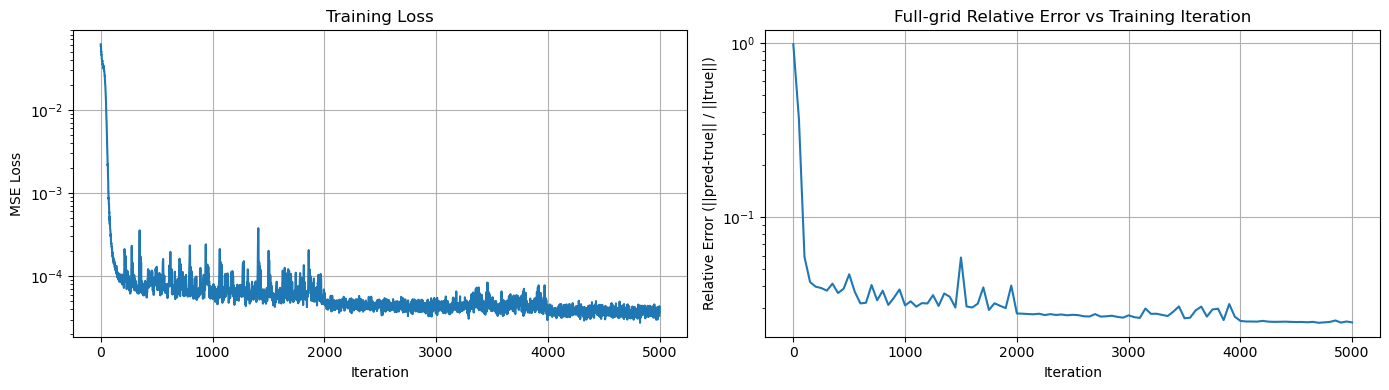

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(losses)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

iters, rels = zip(*rel_errors)
axes[1].semilogy(iters, rels)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Relative Error (||pred-true|| / ||true||)')
axes[1].set_title('Full-grid Relative Error vs Training Iteration')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluate: compare predicted vs true gradient on a slice

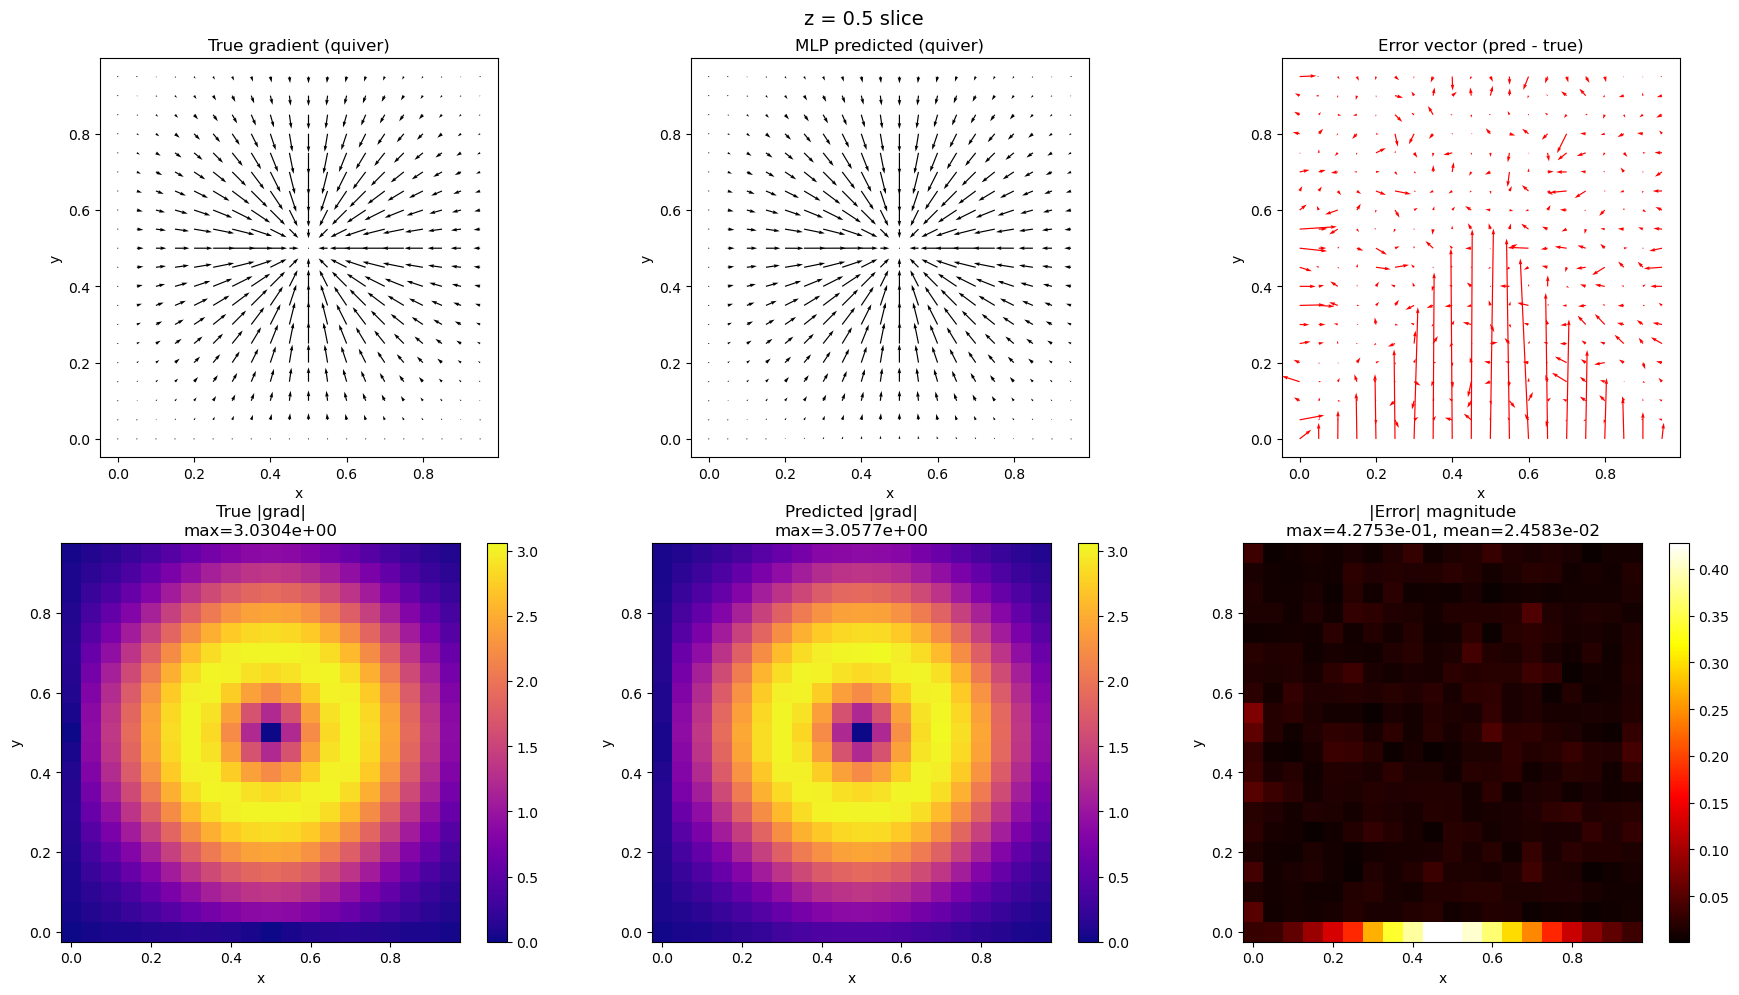

In [45]:
# Take a z=0.5 slice through the field
n_vis = 20  # quiver grid resolution
xy = torch.linspace(0, L - L/n_vis, n_vis, device=device)
Xv, Yv = torch.meshgrid(xy, xy, indexing='ij')
z_slice = 0.5
slice_pos = torch.stack([Xv.reshape(-1), Yv.reshape(-1),
                         torch.full((n_vis*n_vis,), z_slice, device=device)], dim=1)

model.eval()
with torch.no_grad():
    pred_norm = model(slice_pos)
    pred_slice = pred_norm * grad_scale  # un-normalize

# True gradient at those positions (trilinear interpolation)
from cell_gnn.generators.particle_spring_force_ode_static_field import trilinear_sample_periodic

gx_s, gy_s, gz_s = trilinear_sample_periodic(
    [gc_x, gc_y, gc_z], slice_pos.double(), L, Nx)
true_slice = torch.stack([gx_s, gy_s, gz_s], dim=1).float()

# Convert to numpy
xn = Xv.cpu().numpy()
yn = Yv.cpu().numpy()
pred_np = pred_slice.cpu().numpy().reshape(n_vis, n_vis, 3)
true_np = true_slice.cpu().numpy().reshape(n_vis, n_vis, 3)

true_mag = np.sqrt(true_np[:,:,0]**2 + true_np[:,:,1]**2 + true_np[:,:,2]**2)
pred_mag = np.sqrt(pred_np[:,:,0]**2 + pred_np[:,:,1]**2 + pred_np[:,:,2]**2)
err = pred_np - true_np
err_mag = np.sqrt(err[:,:,0]**2 + err[:,:,1]**2 + err[:,:,2]**2)

# Shared color range for true/pred magnitude
vmin_mag = min(true_mag.min(), pred_mag.min())
vmax_mag = max(true_mag.max(), pred_mag.max())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: vector fields (quiver) ---
axes[0,0].quiver(xn, yn, true_np[:,:,0], true_np[:,:,1])
axes[0,0].set_title('True gradient (quiver)')

axes[0,1].quiver(xn, yn, pred_np[:,:,0], pred_np[:,:,1])
axes[0,1].set_title('MLP predicted (quiver)')

axes[0,2].quiver(xn, yn, err[:,:,0], err[:,:,1], color='red')
axes[0,2].set_title('Error vector (pred - true)')


# --- Row 2: magnitudes (heatmaps) ---
im0 = axes[1,0].pcolormesh(xn, yn, true_mag, cmap='plasma', vmin=vmin_mag, vmax=vmax_mag)
axes[1,0].set_title(f'True |grad|\nmax={true_mag.max():.4e}')
plt.colorbar(im0, ax=axes[1,0])

im1 = axes[1,1].pcolormesh(xn, yn, pred_mag, cmap='plasma', vmin=vmin_mag, vmax=vmax_mag)
axes[1,1].set_title(f'Predicted |grad|\nmax={pred_mag.max():.4e}')
plt.colorbar(im1, ax=axes[1,1])

im2 = axes[1,2].pcolormesh(xn, yn, err_mag, cmap='hot')
axes[1,2].set_title(f'|Error| magnitude\nmax={err_mag.max():.4e}, mean={err_mag.mean():.4e}')
plt.colorbar(im2, ax=axes[1,2])


for ax in axes.flat:
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('z = 0.5 slice', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# Overall R^2 and relative error on full grid
model.eval()
with torch.no_grad():
    pred_all = model(positions_dev) * grad_scale
    true_all = grad_targets.to(device)
    mse = nn.functional.mse_loss(pred_all, true_all).item()
    ss_res = ((pred_all - true_all)**2).sum().item()
    ss_tot = ((true_all - true_all.mean(dim=0))**2).sum().item()
    r2 = 1 - ss_res / ss_tot
    rel_err = (torch.norm(pred_all - true_all) / torch.norm(true_all)).item()

print(f'Full-grid MSE:            {mse:.6e}')
print(f'Full-grid R^2:            {r2:.6f}')
print(f'Full-grid relative error: {rel_err:.4f}')

Full-grid MSE:            3.415781e-04
Full-grid R^2:            0.999383
Full-grid relative error: 0.0248
